# Personalization:


In [1]:
from cProfile import label

import pandas as pd
import numpy as np
import cv2
from pathlib import Path
import os
import time

In [ ]:
root_folder = Path("./personalization/")
text_files = []
video_files = []

for f,folder in enumerate(root_folder.iterdir()):

    if folder.is_dir():

        # print(f"\nfolder_name: {folder.name}")
        images_folder = Path(f"{root_folder}/{folder.name}/images")
        images_folder.mkdir(
                parents=True,
                exist_ok=True
            )
        # os.makedirs("images", exist_ok=True)

        for file in folder.iterdir():

            if file.suffix == ".txt" and file.name == f"{folder.name}_position.txt":
                # print("TXT gefunden:", file)
                txt_file = Path(f"{root_folder}/{folder.name}/{folder.name}_position.txt")
                # print(f"Text_File: {txt_file.as_posix()}\n")
                text_files.append(txt_file.as_posix())


                

            elif file.suffix == ".mp4":
                # print("MP4 gefunden:", file)
                video_file = Path(f"{root_folder}/{folder.name}/{folder.name}_video.mp4")
                # print(f"Video_File: {video_file.as_posix()}\n")
                video_files.append(video_file.as_posix())

print(f"\nText_Files: {text_files}")
print(f"\nlen(Text_Files) : {len(text_files)}")

print(f"\nVideo_Files: {video_files}")
print(f"\nlen(Text_Files) : {len(text_files)}")





# step 3:

for i in range(len(text_files)):

    labels = pd.read_csv(text_files[i], sep=",") 
    # print(labels.head())
    # print(labels.columns)

    labels.columns = labels.columns.str.strip()

    # subject_name = f"{text_files[i].split('/')[1]}"
    subject_name = Path(text_files[i]).parent.name
    
    print(f"\nsubject_name: {subject_name}\n")

    images_folder = Path(f"./personalization") / subject_name / "images"

    images_folder.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_files[i])

    rows = []
    norm_rows = []
    frame_id = 0
    saved_id = 0

    FPS = 30
    Steps = 5

    effective_fps = FPS / Steps

    # print(f"Original FPS: {FPS}")
    # print(f"Steps: {Steps}")
    # print(f"Effektive FPS: {effective_fps}")

    # Min und Max berechnen
    x_min = labels["x"].min()
    x_max = labels["x"].max()

    y_min = labels["y"].min()
    y_max = labels["y"].max()

    # print(f"x_min = {x_min}, x_max = {x_max}")
    # print(f"y_min = {y_min}, y_max = {y_max}")
    # x_min = 7.25, x_max = 1422.74
    # y_min = 3.89, y_max = 875.01
    
    # sys1 = "Surface"
    # sys2 = "HP"
    if subject_name == '01' or subject_name == '02' or subject_name == '03' or subject_name == '04': 
        x_max, y_max = 1430, 880
        # x_max, y_max = 1870, 1000
        
        # print(f"System: {sys1}")
        # print(f"\nX_max = {x_max}, Y_max = {y_max}")

    if (
        subject_name == '05' or subject_name == '06' or subject_name == '07' or subject_name == '08' or subject_name == '09' 
        or subject_name == '07' or subject_name == '08' or subject_name == '09'):
        # x_max, y_max = 1430, 880
        x_max, y_max = 1870, 1000
        
        # print(f"System: {sys2}")
        # print(f"\nX_max = {x_max}, Y_max = {y_max}")
        
    # print(f"X_max = {x_max}, Y_max = {y_max}")
    # X_max = 1430, Y_max = 880

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % Steps == 0:

            filename = f"{saved_id:04d}.jpg"

            image_path = images_folder / filename

            cv2.imwrite(str(image_path), frame)


            rows.append({
                "frame": filename,
                "x": max(0, float(f"{(labels.loc[frame_id, "x"]):.6f}")),
                "y": max(0, float(f"{(labels.loc[frame_id, "y"]):.6f}"))
            })

            norm_rows.append({
                "frame": filename,
                "x": min(max(0, float(f"{(labels.loc[frame_id, "x"] / x_max):.6f}")), 1),
                "y": min(max(0, float(f"{(labels.loc[frame_id, "y"] / y_max):.6f}")), 1)
            })

            saved_id += 1


        frame_id += 1

    cap.release()

    pd.DataFrame(rows).to_csv(
        f"./personalization/{subject_name}/labels.csv", index=False
    )

    pd.DataFrame(norm_rows).to_csv(
        f"./personalization/{subject_name}/norm_labels.csv", index=False
        )


Text_Files: ['personalization/01/01_position.txt', 'personalization/02/02_position.txt', 'personalization/03/03_position.txt', 'personalization/04/04_position.txt', 'personalization/05/05_position.txt', 'personalization/06/06_position.txt', 'personalization/07/07_position.txt', 'personalization/08/08_position.txt', 'personalization/09/09_position.txt', 'personalization/10/10_position.txt', 'personalization/11/11_position.txt', 'personalization/12/12_position.txt']

len(Text_Files) : 12

Video_Files: ['personalization/01/01_video.mp4', 'personalization/02/02_video.mp4', 'personalization/03/03_video.mp4', 'personalization/04/04_video.mp4', 'personalization/05/05_video.mp4', 'personalization/06/06_video.mp4', 'personalization/07/07_video.mp4', 'personalization/08/08_video.mp4', 'personalization/09/09_video.mp4', 'personalization/10/10_video.mp4', 'personalization/11/11_video.mp4', 'personalization/12/12_video.mp4']

len(Text_Files) : 12


# Nur für Session 10, 11, 12, wenn man andere Struktur braucht:

In [13]:
# ==========================================================
# Video + Labels verarbeiten
# ==========================================================

for i in range(len(text_files)):

    if str(i+1) in ['10', '11', '12']:

        # ------------------------------------------------------
        # Subject bestimmen
        # ------------------------------------------------------

        subject_name = Path(text_files[i]).parent.name

        # print(f"\n========================================")
        print(f"\n\nSubject: {subject_name}\n")
        # print(f"========================================")


        # ------------------------------------------------------
        # Neues / altes Format erkennen
        # ------------------------------------------------------

        new_format = True       #  Format: segment_id + frame + x + y + phase


        # ------------------------------------------------------
        # Labels laden
        # ------------------------------------------------------
        labels = pd.read_csv(
            text_files[i],
            sep=","
        )

        labels.columns = labels.columns.str.strip()


        # ------------------------------------------------------
        # Prüfen, ob erwartete Spalten vorhanden sind
        # ------------------------------------------------------

        required_columns = [
            "segment_id",
            "frame",
            "x",
            "y",
            "phase"
        ]


        missing_columns = [
            col for col in required_columns
            if col not in labels.columns
        ]

        if missing_columns:

            raise ValueError(
                f"Subject {subject_name}: "
                f"folgende Spalten fehlen: {missing_columns}"
            )


        # ------------------------------------------------------
        # Frame als Index setzen
        # ------------------------------------------------------
        labels["frame"] = labels["frame"].astype(int)
        labels = labels.set_index("frame")

        # ------------------------------------------------------
        # Images-Ordner
        # ------------------------------------------------------
        images_folder = Path("./personalization") / subject_name / "images"

        images_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        # ------------------------------------------------------
        # Video öffnen
        # ------------------------------------------------------
        cap = cv2.VideoCapture(video_files[i])

        if not cap.isOpened():

            raise RuntimeError(
                f"Video konnte nicht geöffnet werden: "
                f"{video_files[i]}"
            )


        # ------------------------------------------------------
        # Listen für CSV
        # ------------------------------------------------------

        rows = []
        rows2 = []
        norm_rows = []
        norm_rows2 = []

        frame_id = 0
        saved_id = 0

        FPS = 30
        Steps = 5

        effective_fps = FPS / Steps


        # ======================================================
        # Bildschirmgröße für Normalisierung
        # ======================================================
        x_max = 1870
        y_max = 1000


        # ======================================================
        # Video Frame für Frame lesen
        # ======================================================
        while True:

            ret, frame = cap.read()

            if not ret:
                break


            # --------------------------------------------------
            # Nur jedes 5. Frame speichern
            # --------------------------------------------------
            if frame_id % Steps == 0:

                # ----------------------------------------------
                # Prüfen, ob Label für diesen Frame existiert
                # ----------------------------------------------
                if frame_id not in labels.index:

                    print(
                        f"Warnung: Kein Label für "
                        f"Frame {frame_id}"
                    )

                    frame_id += 1

                    continue


                # ----------------------------------------------
                # Label holen
                # ----------------------------------------------
                label = labels.loc[frame_id]

                x = max(0, float(label["x"]))
                y = max(0, float(label["y"]))

                # ----------------------------------------------
                # Bild speichern
                # ----------------------------------------------
                filename = f"{saved_id:04d}.jpg"

                image_path = images_folder / filename

                cv2.imwrite(
                    str(image_path),
                    frame
                )

                # ==================================================
                # LABELS.CSV
                # ==================================================
                rows.append({
                    "frame": filename,
                    "x": x,
                    "y": y
                })

                rows2.append({
                    "segment_id": int(label["segment_id"]),
                    "frame": filename,
                    "x": x,
                    "y": y,
                    "phase": label["phase"]
                })



                # ==================================================
                # NORMALISIERTE LABELS
                # ==================================================
                x_norm = min(max(0, x / x_max), 1)
                y_norm = min(max(0, y / y_max), 1)


                norm_rows2.append({
                    "segment_id": int(label["segment_id"]),
                    "frame": filename,
                    "x": round(x_norm, 6),
                    "y": round(y_norm, 6),
                    "phase": label["phase"]
                })

                norm_rows.append({
                    "frame": filename,
                    "x": round(x_norm, 6),
                    "y": round(y_norm, 6)
                })

                saved_id += 1


            frame_id += 1


        # ------------------------------------------------------
        # Video schließen
        # ------------------------------------------------------

        cap.release()


        # ======================================================
        # CSV speichern
        # ======================================================

        output_folder = (
            Path("./personalization")
            / subject_name
        )


        pd.DataFrame(rows).to_csv(
            output_folder / "labels.csv",
            index=False
        )
        

        pd.DataFrame(rows2).to_csv(
                output_folder / "labels2.csv",
                index=False
            )


        pd.DataFrame(norm_rows).to_csv(
            output_folder / "norm_labels.csv",
            index=False
        )


        pd.DataFrame(norm_rows2).to_csv(
            output_folder / "norm_labels2.csv",
            index=False
        )

    else:
        continue




Subject: 10



Subject: 11



Subject: 12



# Random and Constant Error

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np


norm_labels_files = []


for folder in sorted(root_folder.iterdir()):

    if folder.is_dir():

        norm_file = folder / "norm_labels.csv"


        if not norm_file.exists():

            print(f"Fehlt: {file.resolve()}")

        else:

            norm_labels_files.append(norm_file.as_posix())



print(f"norm_files:{norm_labels_files}")
print(f"Anzahl der norm_files: {len(norm_labels_files)}\n")

# df2 = pd.read_csv(norm_labels_files[0])

# print(df2.head())

random_baseline = []
constant_baseline = []

for i in range(len(norm_labels_files)):

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: ----------------------------
# -------------------------------------------------------------------

    norm_label = (norm_labels_files[i])
    # print(f"norm_file: {norm_label}")
    # norm_label = Path('./personalization/01/norm_labels.csv')
    df2 = pd.read_csv(norm_label)
    # print(df2.head())



    x_true = df2["x"].values
    y_true = df2["y"].values

    x_const = np.mean(x_true)
    y_const = np.mean(y_true)



    pred_x_const = np.full_like(x_true, x_const)
    pred_y_const = np.full_like(y_true, y_const)

    const_errors = np.sqrt(
        (x_true - pred_x_const) ** 2 +
        (y_true - pred_y_const) ** 2
    )


    mae = np.mean(const_errors)
    rmse = np.sqrt(np.mean(const_errors ** 2))
    const_error_pct = np.round(100 * rmse, 5)
    const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    print(f"\nKonstant Baseline: {norm_label}\n")
    # print(f"Constant_Mean_Absolute_Error: {mae}")
    # print(f"Constant_Mean_Squared_Error: {rmse}")
    # print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
    print(f"Constant_Diagonal-Error: \t {const_diagonal_error_pct} %")
    constant_baseline.append(const_diagonal_error_pct)


    # -------------------------------------------------------------------
    # ---------------------- Random-Error -------------------------------
    # -------------------------------------------------------------------

    x = df2["x"]
    y = df2["y"]
    x_max = np.max(x)
    x_min = np.min(x)
    y_max = np.max(y)
    y_min = np.min(y)



    pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
    pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

    random_errors = np.sqrt(
        (x_true - pred_x_random)**2 +
        (y_true - pred_y_random)**2
    )

    mae = np.mean(random_errors)
    rmse = np.sqrt(np.mean(random_errors ** 2))
    random_error_pct = np.round(100 * rmse, 5)
    random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    # print(f"\nRandom Baseline: {norm_label}\n")
    # print(f"Random_Mean_Absolute_Error: {mae}")
    # print(f"Random_Mean_Squared_Error: {rmse}")
    # print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
    print(f"Random_Diagonal-Error : \t {random_diagonal_error_pct} % \n\n")
    random_baseline.append(random_diagonal_error_pct)


print(f"Mean constant_Diagonal_Error: \t {np.mean(constant_baseline):.6f} % ")
print(f"Mean Random_Diagonal_Error: \t {np.mean(random_baseline):.6f} % ")


Fehlt: F:\project\Venv\gaze-estimation\personalization\011\norm_labels.csv
norm_files:['personalization/01/norm_labels.csv', 'personalization/02/norm_labels.csv', 'personalization/03/norm_labels.csv', 'personalization/04/norm_labels.csv', 'personalization/05/norm_labels.csv', 'personalization/06/norm_labels.csv', 'personalization/07/norm_labels.csv', 'personalization/08/norm_labels.csv', 'personalization/09/norm_labels.csv', 'personalization/10/norm_labels.csv', 'personalization/11/norm_labels.csv', 'personalization/12/norm_labels.csv']
Anzahl der norm_files: 12


Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error: 	 28.77637 %
Random_Diagonal-Error : 	 40.56728 % 



Konstant Baseline: personalization/02/norm_labels.csv

Constant_Diagonal-Error: 	 29.30417 %
Random_Diagonal-Error : 	 41.53779 % 



Konstant Baseline: personalization/03/norm_labels.csv

Constant_Diagonal-Error: 	 28.75691 %
Random_Diagonal-Error : 	 40.62908 % 



Konstant Baseline: personal

# Konstant Baseline: personalization/01/norm_labels.csv
Constant_Diagonal-Error: 	 28.77637 %

Random_Diagonal-Error : 	 40.81677 % 


# Konstant Baseline: personalization/02/norm_labels.csv
Constant_Diagonal-Error: 	 29.30417 %

Random_Diagonal-Error : 	 39.33601 % 


# Konstant Baseline: personalization/03/norm_labels.csv
Constant_Diagonal-Error: 	 28.75691 %

Random_Diagonal-Error : 	 40.4452 % 


# Konstant Baseline: personalization/04/norm_labels.csv
Constant_Diagonal-Error: 	 28.50943 %

Random_Diagonal-Error : 	 40.22785 % 


# Konstant Baseline: personalization/05/norm_labels.csv
Constant_Diagonal-Error: 	 30.88308 %

Random_Diagonal-Error : 	 42.63929 % 


# Konstant Baseline: personalization/06/norm_labels.csv
Constant_Diagonal-Error: 	 27.4493 %

Random_Diagonal-Error : 	 40.99957 % 


# Konstant Baseline: personalization/07/norm_labels.csv
Constant_Diagonal-Error: 	 28.45881 %

Random_Diagonal-Error : 	 43.08576 % 


# Konstant Baseline: personalization/08/norm_labels.csv
Constant_Diagonal-Error: 	 26.94685 %

Random_Diagonal-Error : 	 39.74176 % 


# Konstant Baseline: personalization/09/norm_labels.csv
Constant_Diagonal-Error: 	 25.86613 %

Random_Diagonal-Error : 	 36.34756 % 


# Konstant Baseline: personalization/10/norm_labels.csv
Constant_Diagonal-Error: 	 32.3304 %

Random_Diagonal-Error : 	 43.64972 % 


# Konstant Baseline: personalization/11/norm_labels.csv
Constant_Diagonal-Error: 	 35.94951 %

Random_Diagonal-Error : 	 46.30599 % 


# Konstant Baseline: personalization/12/norm_labels.csv
Constant_Diagonal-Error: 	 34.77597 %

Random_Diagonal-Error : 	 45.67593 % 
 

## ============================================================

# Mean-Baseline of Sessions:
Mean constant_Diagonal_Error: 	    29.833911 % 

Mean Random_Diagonal_Error: 	    41.719377 % 





## Evaluation: without train

In [7]:
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm




In [8]:
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [9]:
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [10]:

# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
dataset = PersonalGazeDataset(
    root_dir="./personalization/10",
    transform=transform
)

print(f"\nPfade: {dataset.root_dir}\n")

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1468/1468 [00:15<00:00, 93.99it/s]


Pfade: personalization/10



In [13]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
        nn.Linear(
            model.fc.in_features,
            512
        ),
        nn.ReLU(),
        nn.Linear(
            512,
            128
        ),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(
            128,
            2
        ),
        nn.Sigmoid()
    )



Model: ResNet


In [14]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
checkpoint = torch.load(
    "./models/ResNet_optim-model_norm_subject_1000-200.path",
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [15]:
print(f"\nBaseline-Erorr:")
baseline_mae, baseline_rmse, baseline_diag_pct = diagonal_errors(model, loader, device)
# diag_train_error.append(np.round(train_diag_pct, 4))

print(f"baseline_diag_error={baseline_diag_pct:.4f}%")




Baseline-Erorr:
MAE : 0.3004 	 RMSE: 0.3446 
Diagonal-Error %: 24.3690 %
baseline_diag_error=24.3690%


# Subject: 01
Baseline-Erorr:

MAE : 0.2554 	 RMSE: 0.2979 

Diagonal-Error %: 21.0671 %

baseline_diag_error=21.0671%

# Subject: 02
Baseline-Erorr:

MAE : 0.2543 	 RMSE: 0.2927 

Diagonal-Error %: 20.6937 %

baseline_diag_error=20.6937%

# Subject: 03
Baseline-Erorr:

MAE : 0.2513 	 RMSE: 0.2900 

Diagonal-Error %: 20.5044 %

baseline_diag_error=20.5044%

# Subject: 04
Baseline-Erorr:

MAE : 0.2569 	 RMSE: 0.3003 

Diagonal-Error %: 21.2322 %

baseline_diag_error=21.2322%

# Subject: 10

Baseline-Erorr:

MAE : 0.3004 	 RMSE: 0.3446 

Diagonal-Error %: 24.3690 %

baseline_diag_error=24.3690%


## Evaluation: Train: 

In [29]:
# 0: Lib
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm
import time
import os
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from torch.utils.data import DataLoader, Subset, random_split



In [17]:
# 1: calss PersonalGazeDataset
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
            # self.root_dir 
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [18]:
# 2: func diagonal_error
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [19]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    return targets, predictions, errors

In [20]:
# Hypoparameter:
batch_size = 64

epochs = 200

patience = 3                   # after 3 Epochen without Optimierung has to stop training

learning_rate = 1e-5    # 1e-4, 1e-5  

session = "10"

best_model_name = "./models/ResNet_best_optim-model_norm_subject_1000-200.path"


In [21]:
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:

dirs = f"personalization/{session}"

pfad = Path(dirs)/"norm_labels.csv"

if not pfad.exists():
    print(f"Fehlt: {pfad.resolve()}")

else:
    csv_pfad = pfad.as_posix()

print(f"csv_pfad: {csv_pfad}")


df3 = pd.read_csv(csv_pfad)
len_df3 = len(df3)
print(f"len(df3):{len_df3}")



train_size = int(np.round(len_df3) * 0.7) 
validat_size = int(np.round(len_df3) * 0.15) 
test_size = len_df3 - (train_size + validat_size)


sum_tvt = train_size + validat_size + test_size


print(f"\n train_size: {train_size}" 
      f"\n validat_size: {validat_size}" 
      f"\n test_size: {test_size} \n"
)

# print(f"validat_size: {validat_size}")
# print(f"test_size: {test_size}")
sum_tvt = train_size + validat_size + test_size
print(f"Summe : {sum_tvt}")

print(f"{ int(len_df3) == int(sum_tvt) }")


csv_pfad: personalization/10/norm_labels.csv
len(df3):1468

 train_size: 1027
 validat_size: 220
 test_size: 221 

Summe : 1468
True


In [23]:
# dataset = PersonalGazeDataset(
#     root_dir=root_dirs,
#     transform=transform
# )

train_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=train_size,
)


validat_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
    dataset_size=validat_size,
)


test_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=test_size,
)


print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")




# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [00:01<00:00, 111.64it/s]


 len(train_dataset): 1027
 len(validat_dataset):  220
 len(test_dataset): 221


In [22]:
## Test:
# batch = next(iter(train_loader))

# images, targets = batch

# print(images.shape)
# print(targets.shape)

In [24]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    nn.Sigmoid()
)

active_func = 'Sigmoid'


Model: ResNet


In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
# checkpoint = torch.load(
#     "./models/ResNet_optim-model_norm_subject_1000-200.path",
#     map_location=device
# )

checkpoint = torch.load(
    best_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [26]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()


for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True
    

for param in model.fc.parameters():
    param.requires_grad=True


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)


In [28]:
import os

model_output = './models/personal'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

train_start = time.perf_counter()
print(f"\nSession: {session}\n")

best_error = None
diag_val_error, diag_train_error = [], []


t = 0                      # Number Epochen without Optimierung
e = 0                      # Number Epochen with Optimierung

# patience = 4               # after 4 Epochen without Optimierung has to stop training

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()
    
    print(f"\n train_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\n valid_error:")
    valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
    diag_val_error.append(np.round(valid_diag_pct, 4))

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------
    
    if best_error is None or valid_diag_pct < best_error:
    
        # find an improvement
        best_error = valid_diag_pct
        t = 0
        e += 1
    
        print(
            f"Validation-Diagonal-Error: {valid_diag_pct:.4f}% | "
            f"Improvment: {e}"
        )
    
        # save the better Modell
        torch.save(
            model.state_dict(),
            f"./models/personal/{model_name}_best_model_lr({learning_rate})_"
            f"session({session}).path"
        )
    
    else:
    
        # without imporovement
        t += 1
    
        print(
            f"Patience: {t}/{patience}"
        )
    
        if t >= patience:
            print(
                f"\nEarly Stopping after {epoch + 1} Epochen."
            )
            print(
                f"Imporovments totally: {e}"
            )
            break
    
    

    epoch_end = time.perf_counter()

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"validation_diag_error={valid_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% \n"
    )

    torch.save(
            model.state_dict(),
            f"./models/personal/{model_name}_last_model_lr({learning_rate})_"
            f"session({session}).path"
        )


train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"min Epochs: {e}\n")
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")


# end_time = time.perf_counter()
# elapsed_time = end_time - start_time
# print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
# print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


Session: 10



Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [01:01<00:00,  3.64s/it, loss=0.0408]



 train_error:
MAE : 0.2870 	 RMSE: 0.3200 
Diagonal-Error %: 22.6239 %

 valid_error:
MAE : 0.2680 	 RMSE: 0.3045 
Diagonal-Error %: 21.5298 %
Validation-Diagonal-Error: 21.5298% | Improvment: 1

[00:42:07] Epoch 1: 131.04 Sekunden | Running_loss: 0.051 | validation_diag_error=21.5298% | train_diag_error=22.6239% 



Epoch 2: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [01:18<00:00,  4.63s/it, loss=0.0417]



 train_error:
MAE : 0.2826 	 RMSE: 0.3155 
Diagonal-Error %: 22.3082 %

 valid_error:
MAE : 0.2637 	 RMSE: 0.2997 
Diagonal-Error %: 21.1891 %
Validation-Diagonal-Error: 21.1891% | Improvment: 2

[00:44:32] Epoch 2: 144.78 Sekunden | Running_loss: 0.050 | validation_diag_error=21.1891% | train_diag_error=22.3082% 



...


 train_error:
MAE : 0.0640 	 RMSE: 0.0816 
Diagonal-Error %: 5.7666 %

 valid_error:
MAE : 0.1244 	 RMSE: 0.1711 
Diagonal-Error %: 12.0989 %
Patience: 1/3

[02:23:24] Epoch 44: 141.35 Sekunden | Running_loss: 0.005 | validation_diag_error=12.0989% | train_diag_error=5.7666% 



Epoch 45: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [01:14<00:00,  4.41s/it, loss=0.0367]



 train_error:
MAE : 0.0614 	 RMSE: 0.0785 
Diagonal-Error %: 5.5483 %

 valid_error:
MAE : 0.1226 	 RMSE: 0.1720 
Diagonal-Error %: 12.1621 %
Patience: 2/3

[02:25:44] Epoch 45: 139.97 Sekunden | Running_loss: 0.006 | validation_diag_error=12.1621% | train_diag_error=5.5483% 



Epoch 46: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [01:16<00:00,  4.49s/it, loss=0.0104]



 train_error:
MAE : 0.0595 	 RMSE: 0.0755 
Diagonal-Error %: 5.3415 %

 valid_error:
MAE : 0.1254 	 RMSE: 0.1734 
Diagonal-Error %: 12.2617 %
Patience: 3/3

Early Stopping after 46 Epochen.
Imporovments totally: 37
min Epochs: 37


totll running-tiems (s): 6490.10 Sekunden
totll running-tiems (min): 108.17 Minuten





 Diagonal-Train-Error: [22.6239 22.3082 21.9932 21.6558 21.322  20.968  20.6668 20.3626 19.9561
 19.698  19.3102 18.8746 18.4294 17.9995 17.5847 17.0488 16.3649 15.9088
 15.1756 14.5875 14.0428 13.4865 12.9364 12.4292 11.8209 11.2758 10.7859
 10.4565 10.0634  9.7467  9.2643  8.8752  8.4426  8.2829  7.7616  7.5128
  7.1456  7.013   6.8862  6.6474  6.1033  6.1769  5.7923  5.7666  5.5483
  5.3415]

 Diagonal-Test-Error: [21.5298 21.1891 20.8052 20.3291 19.9604 19.5146 19.2372 18.9702 18.3807
 18.2108 17.8119 17.3832 17.0359 16.7713 16.4107 15.9675 15.4837 15.2573
 14.7834 14.5151 14.2853 14.1173 13.9407 13.7066 13.4777 13.2365 13.2417
 13.1509 13.0791 13.0146 12.8853 12.8796 12.609  12.645  12.5244 12.5804
 12.4148 12.3566 12.665  12.2953 12.3971 12.3777 12.0604 12.0989 12.1621
 12.2617]


 Diagonal-Train-Error-Max: 22.6239 	 Diagonal-Train-Error-Min: 5.3415	
 Diagonal-Test-Error-Max: 21.5298	 Diagonal-Test-Error-Min: 12.0604	 max_needed_epochs: 39



Minimum Test Error:
Epoch:         

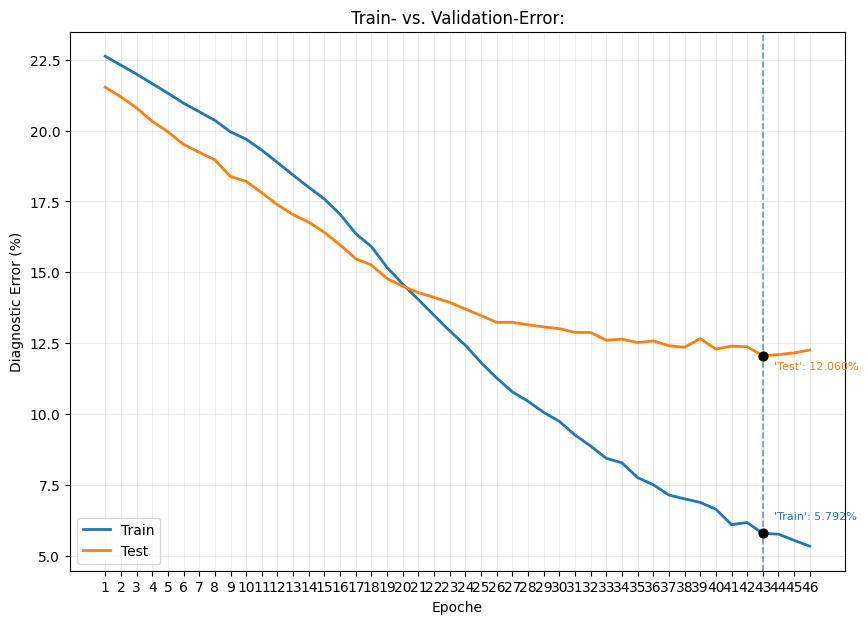

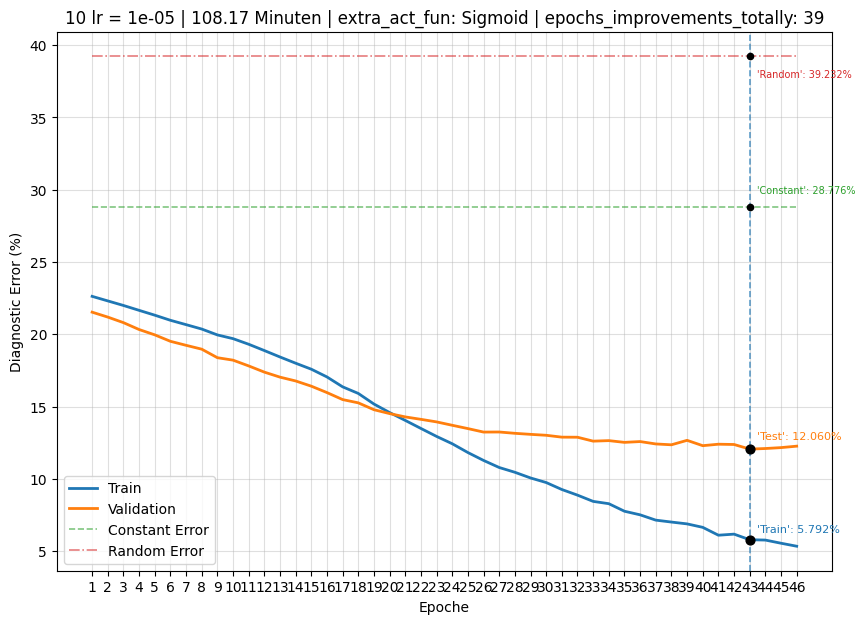

In [31]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_val_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_val_error)}\t Diagonal-Test-Error-Min: {np.min(diag_val_error)}\t max_needed_epochs: {e+2}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")

# Session: 01
if globals().get("bas_const_err") is None:
    bas_const_err = 28.776

if globals().get("bas_rand_err") is None:
    bas_rand_err = 39.232


# Curven:

# Minimum Test Error bestimmen
min_val_error = min(diag_val_error)
min_val_epoch = diag_val_error.index(min_val_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_val_epoch - 1]
val_at_min = diag_val_error[min_val_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
val_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_val_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Validation Error
plt.plot(epochs, diag_val_error, label="Test", linewidth=2, color=val_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=val_color,
    fontsize=8,
)


plt.title("Train- vs. Validation-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Validation Error
plt.plot(
    epochs,
    diag_val_error,
    label="Validation",
    linewidth=2,
    color=val_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_val_epoch}")
print(f"Validation Error:      {val_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_val_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=val_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_val_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_val_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{session} "
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"epochs_improvements_totally: {e + 2}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results/personal", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/personal/diag_error_{session}_{learning_rate}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ---------- Evaluation ----------

In [32]:
# ---------- Evaluation ----------

saved_model_name = "models/personal/ResNet_best_model_lr(1e-05)_session(10).path"


checkpoint = torch.load(
    saved_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()

print(f"Test:\n")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error={test_diag_pct:.4f}% "
    )

targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test:

MAE : 0.1262 	 RMSE: 0.1734 
Diagonal-Error %: 12.2623 %
test_diag_error=12.2623% 


# Test:

MAE : 0.1341 	 RMSE: 0.1672 

Diagonal-Error %: 11.8241 %

test_diag_error=11.8241%

In [33]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    f"results/personal/predictions_{session}.csv",
    index=False
)

# Split:

    a) random: 70% train, 15% validation, 15% test
    b) sequential: first 70% train, next 15% validation, last 15% test

    c) first Video for train and validation, another Video for test

    d1) train and validation: after every 5 Second start movement with a random Startpoint
    d2) test: frames start 0.5 sec after every new Starting

    e) another Video with another camera und lighing-conditions


In [50]:
dirs = f"personalization/{session}"

csv_path = Path(dirs) / "norm_labels.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fehlt: {csv_path.resolve()}")

df = pd.read_csv(csv_path)

dataset_size = len(df)

print(f"Gesamte Daten: {dataset_size}")


# ============================================================
# Vollständiges Dataset
# ============================================================

full_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
)

print(f"len(full_dataset): {len(full_dataset)}")


Gesamte Daten: 498


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 498/498 [00:05<00:00, 93.69it/s]

len(full_dataset): 498


In [58]:
train_size = int(dataset_size * 0.70)
validat_size = int(dataset_size * 0.15)

test_size = dataset_size - train_size - validat_size

print(
    f"\nTrain:      {train_size} | "
    f"Validation: {validat_size} | "
    f"Test:       {test_size} | "
    f"\n\nSumme:      {train_size + validat_size + test_size}"
)



Train:      348 | Validation: 74 | Test:       76 | 

Summe:      498


# Func: Create Splits

In [ ]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

# a) random 

In [67]:

from torch.utils.data import DataLoader, Subset, random_split


train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42
)


print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


# b: Sequential:

In [ ]:
# B1:

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


In [ ]:
# B2: another Split but better: first Test next Train and Validation



all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


# C: one Video for Train and Validation and another Video for Test


In [ ]:
session1, session2 = str('08'), str('09') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")

print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")

print(f"Session2 Test: {session2}-->{len(test_dataset)}")

In [ ]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)


# d: every 5 sec first after 0.5 sec:

In [ ]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)


# Test 

In [ ]:
def verify_dataset(
    dataset,
    csv_file,
    num_samples=20
):

    df = pd.read_csv(csv_file)

    print("=" * 60)
    print("DATASET VERIFICATION")
    print("=" * 60)

    print(f"CSV rows:      {len(df)}")
    print(f"Dataset size:  {len(dataset)}")

    assert len(df) == len(dataset), (
        "CSV und Dataset haben unterschiedliche Größen!"
    )

    num_samples = min(
        num_samples,
        len(dataset)
    )

    for idx in np.linspace(
        0,
        len(dataset) - 1,
        num_samples,
        dtype=int
    ):

        image, target = dataset[idx]

        csv_row = df.iloc[idx]

        csv_target = np.array(
            [
                csv_row["x"],
                csv_row["y"]
            ],
            dtype=np.float32
        )

        dataset_target = target.numpy()

        if not np.allclose(
            csv_target,
            dataset_target,
            atol=1e-6
        ):

            print(
                f"FEHLER bei Index {idx}"
            )

            print(
                "CSV:",
                csv_target
            )

            print(
                "Dataset:",
                dataset_target
            )

            return False

    print(
        f"\n✓ {num_samples} Samples erfolgreich überprüft."
    )

    return True


In [ ]:
verify_dataset(
    full_dataset,
    Path(dirs) / "norm_labels.csv",
    num_samples=20
)

In [ ]:
train_indices = set(train_dataset.indices)
validat_indices = set(validat_dataset.indices)
test_indices = set(test_dataset.indices)

print(
    "Train ∩ Validation:",
    len(train_indices & validat_indices)
)

print(
    "Train ∩ Test:",
    len(train_indices & test_indices)
)

print(
    "Validation ∩ Test:",
    len(validat_indices & test_indices)
)

# Results:
# Train ∩ Validation = 0
# Train ∩ Test       = 0
# Validation ∩ Test  = 0

In [ ]:
all_used = (
    train_indices
    | validat_indices
    | test_indices
)

print(
    "Anzahl verwendeter Samples:",
    len(all_used)
)

# Results: Bei deinem Reset-aware Split darf len(all_used) sogar kleiner als len(full_dataset) sein


In [19]:
# 01:
print(f"the results for Session: {session}")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01


Diagonal_train_error: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden
totll running-tiems (min): 5.19 Minuten



# the results for Session: 01
## only FC and without layer 4

Diagonal_train_error01: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error01: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden

totll running-tiems (min): 5.19 Minuten

In [24]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden
totll running-tiems (min): 4.88 Minuten



# the results for Session: 02

## only FC and without layer 4


Diagonal_train_error02: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error02: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden

totll running-tiems (min): 4.88 Minuten

In [29]:
# 03:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 03

only FC and without layer 4



Diagonal_train_error: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden
totll running-tiems (min): 5.62 Minuten



## the results for Session: 03

# only FC and without layer 4


Diagonal_train_error03: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error03: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden

totll running-tiems (min): 5.62 Minuten


In [51]:
# 04:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 04

only FC and without layer 4



Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden
totll running-tiems (min): 5.57 Minuten



# the results for Session: 04

## only FC and without layer 4


Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden

totll running-tiems (min): 5.57 Minuten


# ==================== Optimal =============================

In [56]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [19.4212 17.7688 16.9373 16.432  15.9572 15.5047 15.0849 14.7342 14.4432
 14.2265 14.0141 13.781  13.5563 13.348  13.1246 12.9289 12.7407 12.5674
 12.3858 12.2026]


Diagonal_test_error: [20.9319 17.7764 15.8419 14.8768 14.4095 14.1325 14.111  14.2164 14.2938
 14.2955 14.1694 13.848  13.4551 13.3329 13.005  12.886  12.8297 12.8031
 12.6214 12.4136]

 epochs: 20, 	 best_Error: 0.17555457971299732
 best_test_error: 12.4136%, 	max_test_Error: 20.9319%

totll running-tiems (s): 574.36 Sekunden
totll running-tiems (min): 9.57 Minuten



In [62]:
# 01:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

only FC and without layer 4



Diagonal_train_error: [15.3648 15.1013 15.1603 14.678  14.3885 14.2098 14.0774 13.9202 13.78
 13.657  13.5354 13.4318 13.3666 13.243  13.1577 13.0428 12.9579 12.9177
 12.7877 12.7263]


Diagonal_test_error: [16.7358 16.2906 16.3221 15.8886 15.7614 15.5712 15.2743 15.2488 15.1827
 15.0881 14.9273 14.8744 14.7402 14.6438 14.6689 14.6622 14.6104 14.5191
 14.4285 14.46  ]

 epochs: 20, 	 best_Error: 0.2040497107098068
 best_test_error: 14.4285%, 	max_test_Error: 16.7358%

totll running-tiems (s): 788.43 Sekunden
totll running-tiems (min): 13.14 Minuten



In [65]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 



Diagonal_train_error: [11.3647 10.2059  9.183   8.3242  7.5884  7.1476  6.4918  5.9299  5.6028
  5.1456  4.8113  4.533   4.2175  4.0028  3.7746  3.6418  3.4019  3.2304
  3.0697  3.1854]


Diagonal_test_error: [13.5827 12.993  12.4911 12.0546 11.8701 11.8472 11.48   10.8924 10.5413
 10.593  10.3502 10.3507 10.138  10.1412 10.1741 10.1195 10.0583  9.904
  9.8323  9.8302]

 epochs: 20, 	 best_Error: 0.1390205620095576
 best_test_error: 9.8302%, 	max_test_Error: 13.5827%

totll running-tiems (s): 1350.90 Sekunden
totll running-tiems (min): 22.51 Minuten



In [12]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 and Sigmoid \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 and Sigmoid 



Diagonal_train_error: [21.2963 20.4879 19.7773 19.1741 18.6438 18.159  17.7288 17.3245 16.9491
 16.5914 16.2423 15.8723 15.5279 15.1753 14.8057 14.446  14.0653 13.6825
 13.2886 12.9093]


Diagonal_test_error: [22.5788 21.8181 21.181  20.6503 20.1906 19.7427 19.3522 18.9706 18.6466
 18.3322 18.0399 17.7275 17.4513 17.1487 16.8487 16.573  16.2839 16.0158
 15.7229 15.4488]

 epochs: 20, 	 best_Error: 0.2184786646452124
 best_test_error: 15.4488%, 	max_test_Error: 22.5788%

totll running-tiems (s): 1438.26 Sekunden
totll running-tiems (min): 23.97 Minuten

